# PayOrFix - EDA

> ### Business Question:
> ### For each department, is attrition primarily driven by compensation variables or structural variables, and does the answer differ meaningfully across departments?

> ##### Hypothesis to be tested:
> ##### 1. Attrition in Sales Department is mostly driven by structural variables.
> ##### 2. Attrition in R&D is driven by satisfaction and involvement.
> ##### 3. The pay gap between stayers and leavers will be small, indicating that it is structure that drives attrition instead of paychecks.

In [15]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import math
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [16]:
# Define a personalized Matplotlib theme
THEMES = {
    "electric_cyan":   ("#22D3EE", "#070B14", "#111827", "#F8FAFC"),
    "neon_emerald":    ("#10E7A5", "#06110E", "#10211C", "#F0FFF9"),
    "electric_blue":   ("#3B82F6", "#060B18", "#101A2E", "#F8FAFF"),
    "amber_noir":      ("#FBBF24", "#0C0A06", "#1C1810", "#FFF9E8"),
    "hot_coral":       ("#FF6B5E", "#120A0A", "#241515", "#FFF4F2"),
    "bright_violet":   ("#A78BFA", "#0B0714", "#191229", "#F8F5FF"),
    "analytics_blue":  ("#0057D9", "#E8EEF7", "#FFFFFF", "#111827"),
    "deep_teal":       ("#00796B", "#E5F2F0", "#FFFFFF", "#102A27"),
    "crimson_pro":     ("#C1123F", "#F5E9EC", "#FFFFFF", "#2A1118"),
    "indigo_clean":    ("#4F46E5", "#ECECF8", "#FFFFFF", "#17172B"),
    "orange_business": ("#D94F00", "#F7EDE6", "#FFFFFF", "#2C1810"),
    "forest_clean":    ("#08783E", "#E8F3EC", "#FFFFFF", "#10291B")
}


def set_master_theme(primary, canvas_bg, plot_bg, text_color):
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 12

    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.labelpad'] = 10

    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.titlepad'] = 18

    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['xtick.major.pad'] = 12
    plt.rcParams['ytick.major.pad'] = 12
    plt.rcParams['axes.labelpad'] = 16
    
    plt.rcParams['figure.facecolor'] = canvas_bg
    plt.rcParams['axes.facecolor'] = plot_bg
    plt.rcParams['figure.figsize'] = (12, 6)
    
    plt.rcParams['patch.facecolor'] = primary
    plt.rcParams['patch.edgecolor'] = text_color
    plt.rcParams['patch.linewidth'] = 1.2
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[primary, '#e74c3c', '#2ecc71', '#f1c40f'])
    plt.rcParams['lines.linewidth'] = 2.5
    
    plt.rcParams['text.color'] = text_color
    plt.rcParams['axes.labelcolor'] = text_color
    plt.rcParams['xtick.color'] = text_color
    plt.rcParams['ytick.color'] = text_color
    plt.rcParams['axes.edgecolor'] = text_color
    
    plt.rcParams['axes.grid'] = False
    plt.rcParams['grid.color'] = '#e0e0e0' if plot_bg in ['#ffffff', 'white'] else '#444444'
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['axes.axisbelow'] = True


def use_theme(theme_name):
    theme_name = theme_name.lower().strip()

    if theme_name not in THEMES:
        print(f"Theme '{theme_name}' not found.")
        print("Available themes:")
        print(", ".join(THEMES.keys()))
        return

    set_master_theme(*THEMES[theme_name])
    print(f"{theme_name.replace('_', ' ').title()} applied as Master Theme.")


use_theme('electric_cyan')

Electric Cyan applied as Master Theme.


In [17]:
# Create essential functions
def save_plot(plot_name):
    output_dir = '../plots'
    os.makedirs(output_dir, exist_ok=True)

    plot_name = plot_name.lower().replace(" ", "_")
    save_path = os.path.join(output_dir, plot_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"{plot_name} saved!")

from matplotlib.patches import FancyBboxPatch

def style_canvas(radius, border_color, border_width):
    fig = plt.gcf()

    canvas_color = fig.get_facecolor()

    width, height = fig.get_size_inches()
    aspect = width / height

    fig.patch.set_facecolor('none')

    canvas = FancyBboxPatch(
        (0.01, 0.01),
        0.995,
        0.995,

        transform=fig.transFigure,

        boxstyle=f"round,pad=0,rounding_size={radius}",

        facecolor=canvas_color,
        edgecolor=border_color,
        linewidth=border_width,

        mutation_aspect=aspect,

        zorder=-10,
        clip_on=False
    )

    fig.add_artist(canvas)

def visualize_plot(plot_title, x_label, y_label, show_grid, rotation=0):
    if show_grid == True:
        plt.grid(axis='y')
        
    plt.title(plot_title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(rotation=rotation, ha='right' if rotation != 0 else 'center')
    plt.subplots_adjust(left=0.105, right=0.94, top=0.88, bottom=0.16)
    style_canvas(
        radius=0.012,
        border_color='#5f6f69',
        border_width=1.6
    )
    save_plot(plot_title)
    print(" " * 62 + "•••")
    print("\n")
    plt.show()
    print("\n")
    

In [18]:
# Read and Dataframe the input data
df = pd.read_csv('../data/Processed/PayOrFixCleanedData.csv')
dfn = pd.read_csv('../data/Processed/PayOrFixNormalizedData.csv')

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Attrition                 1470 non-null   str  
 1   BusinessTravel            1470 non-null   str  
 2   Department                1470 non-null   str  
 3   EnvironmentSatisfaction   1470 non-null   int64
 4   JobInvolvement            1470 non-null   int64
 5   JobLevel                  1470 non-null   int64
 6   JobSatisfaction           1470 non-null   int64
 7   MonthlyIncome             1470 non-null   int64
 8   OverTime                  1470 non-null   str  
 9   PercentSalaryHike         1470 non-null   int64
 10  RelationshipSatisfaction  1470 non-null   int64
 11  StockOptionLevel          1470 non-null   int64
 12  WorkLifeBalance           1470 non-null   int64
 13  YearsSinceLastPromotion   1470 non-null   int64
 14  Attrition_bin             1470 non-null   int64
 15

In [20]:
df.head()

,Attrition,BusinessTravel,Department,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance,YearsSinceLastPromotion,Attrition_bin,OverTime_bin,BusinessTravel_ord
0,Yes,Travel_Rarely,Sales,2,3,2,4,5993,Yes,11,1,0,1,0,1,1,1
1,No,Travel_Frequently,Research & Development,3,2,2,2,5130,No,23,4,1,3,1,0,0,2
2,Yes,Travel_Rarely,Research & Development,4,2,1,3,2090,Yes,15,2,0,3,0,1,1,1
3,No,Travel_Frequently,Research & Development,4,3,1,3,2909,Yes,11,3,0,3,3,0,1,2
4,No,Travel_Rarely,Research & Development,1,3,1,2,3468,No,12,4,1,3,2,0,0,1


class_imbalance saved!
                                                              •••




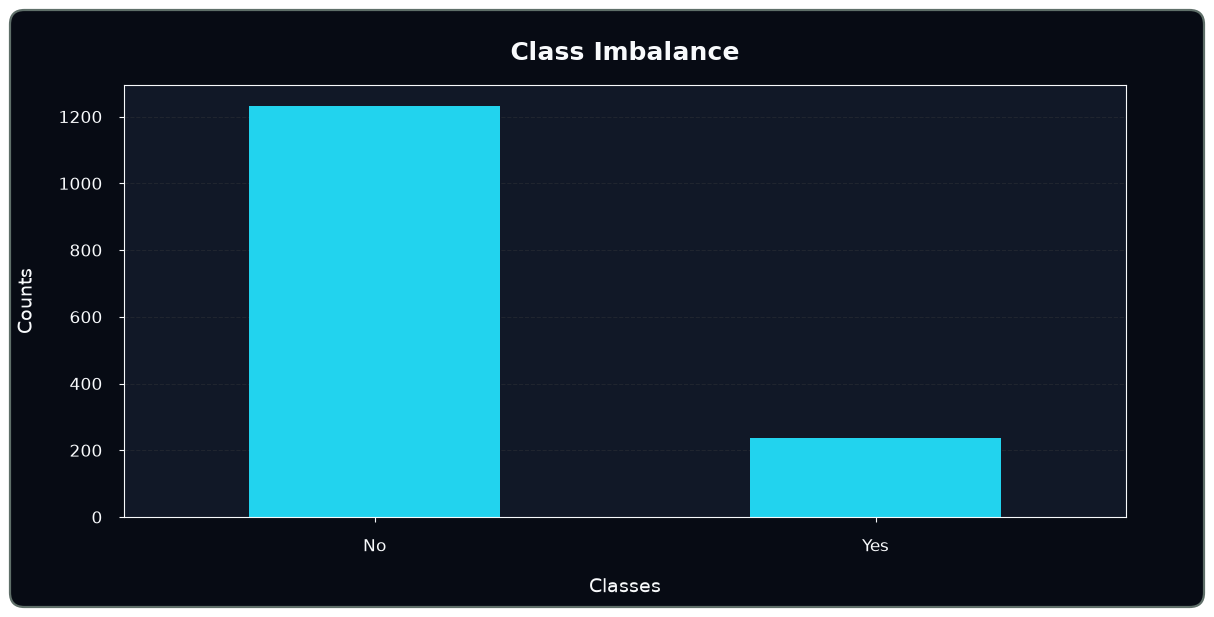

In [21]:
# Determine and visualize the class imbalance
counts = df['Attrition'].value_counts()
counts.plot(kind='bar')
visualize_plot('Class Imbalance', 'Classes', 'Counts', True)

> *The imbalance is massive. "No" are ~6x the "Yes". Keep this in mind during further analysis.*

### Note: Skipping Gender vs Attrition since it may introduce unnecessary Gender bias.

attrition_rate_by_years_since_last_promotion saved!
                                                              •••




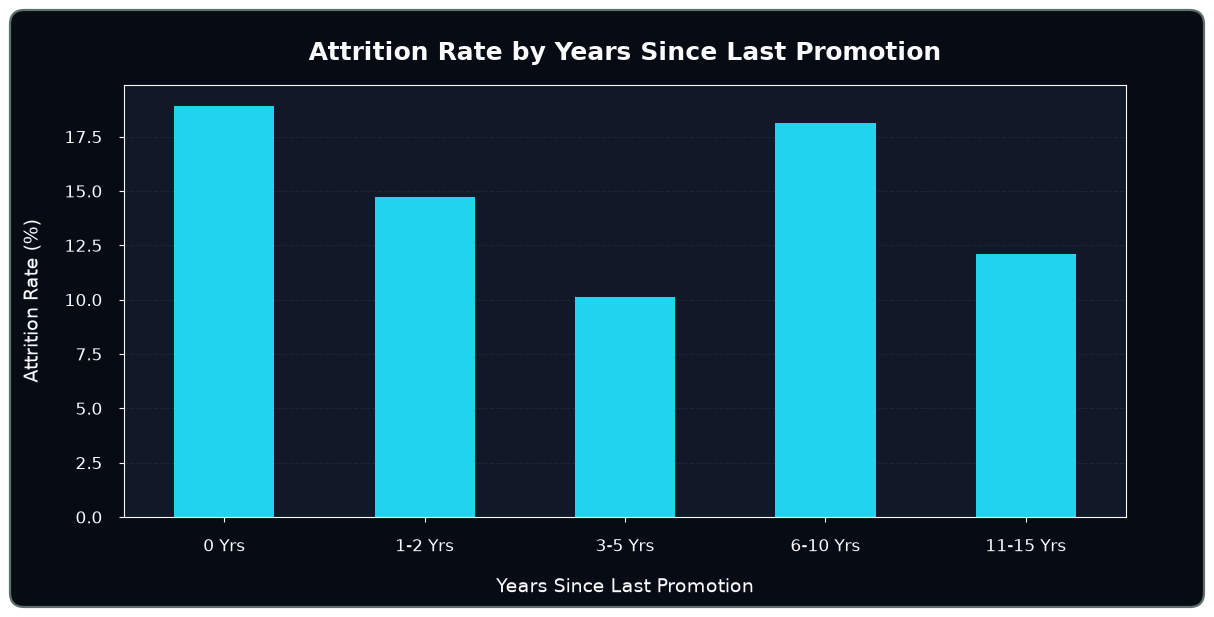

In [22]:
# YearsSinceLastPromotion vs Attrition Rate

df['Promotion_Buckets'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[-1, 0, 2, 5, 10, 15],
    labels=[
        '0 Yrs',
        '1-2 Yrs',
        '3-5 Yrs',
        '6-10 Yrs',
        '11-15 Yrs'
    ]
)

df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

attrition_rate = (
    df.groupby('Promotion_Buckets', observed=True)['Attrition_Flag']
      .mean()
      .mul(100)
)

attrition_rate.plot(kind='bar')

visualize_plot(
    'Attrition Rate by Years Since Last Promotion',
    'Years Since Last Promotion',
    'Attrition Rate (%)',
    True
)

> *Nothing Useful here. Attrition rate is not depending upon years after promotion.*


attrition_rate_by_department saved!
                                                              •••




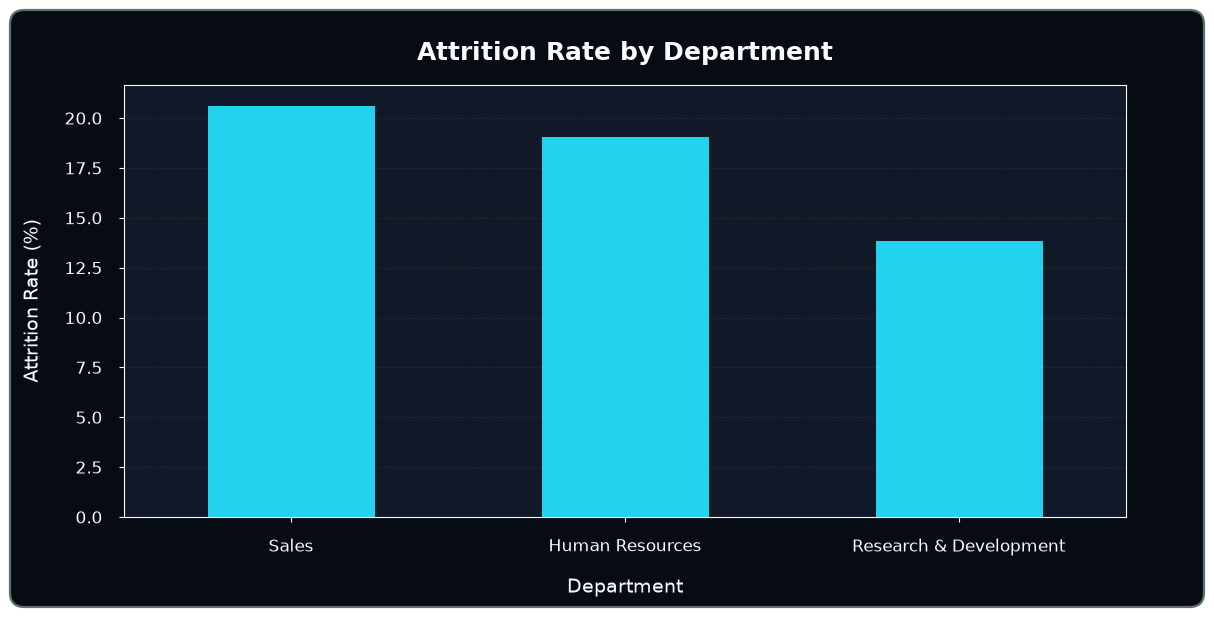

In [23]:
# Department vs Attrition Rate
department_attrition = (
    df.groupby('Department')['Attrition_bin']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

department_attrition.plot(kind='bar')

visualize_plot('Attrition Rate by Department', 'Department', 'Attrition Rate (%)', True)

> *Although the attrition rates in HR and Sales do not differ drastically, R&D has a useful insight here. There is a low attrition rate in R&D than the other two departments.*

In [24]:
# Mean value for leavers vs stayers, company-wide
dfs = dfn[['OverTime_bin', 'WorkLifeBalance', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'JobInvolvement', 'BusinessTravel_ord']].copy()
dfc = dfn[['MonthlyIncome', 'PercentSalaryHike', 'StockOptionLevel', 'JobLevel']].copy()
comp_vars = dfc.columns.to_list()
struct_vars = dfs.columns.to_list()
all_vars = comp_vars + struct_vars
gap_df = df.groupby('Attrition')[all_vars].mean().T
gap_df.columns = ['Stayers', 'Leavers']
gap_df['Gap'] = gap_df['Leavers'] - gap_df['Stayers']
gap_df['Type'] = ['Compensation'] * len(comp_vars) + ['Structural'] * len(struct_vars)

print(gap_df.sort_values('Gap', ascending=False))

                              Stayers      Leavers          Gap          Type
OverTime_bin                 0.234388     0.535865     0.301477    Structural
BusinessTravel_ord           1.056772     1.240506     0.183734    Structural
WorkLifeBalance              2.781022     2.658228    -0.122794    Structural
PercentSalaryHike           15.231144    15.097046    -0.134097  Compensation
RelationshipSatisfaction     2.733982     2.599156    -0.134826    Structural
JobInvolvement               2.770479     2.518987    -0.251491    Structural
EnvironmentSatisfaction      2.771290     2.464135    -0.307155    Structural
JobSatisfaction              2.778589     2.468354    -0.310234    Structural
StockOptionLevel             0.845093     0.527426    -0.317667  Compensation
JobLevel                     2.145985     1.637131    -0.508855  Compensation
MonthlyIncome             6832.739659  4787.092827 -2045.646832  Compensation


> *The numbers here, clearly define the gap that probably translates to attrition. Overtime employees who, on average, worked for 30% more, left the company. Employees who earned more than ~6000 monthly, stayed.*

sales_—_attrition_gap_by_variable saved!
                                                              •••




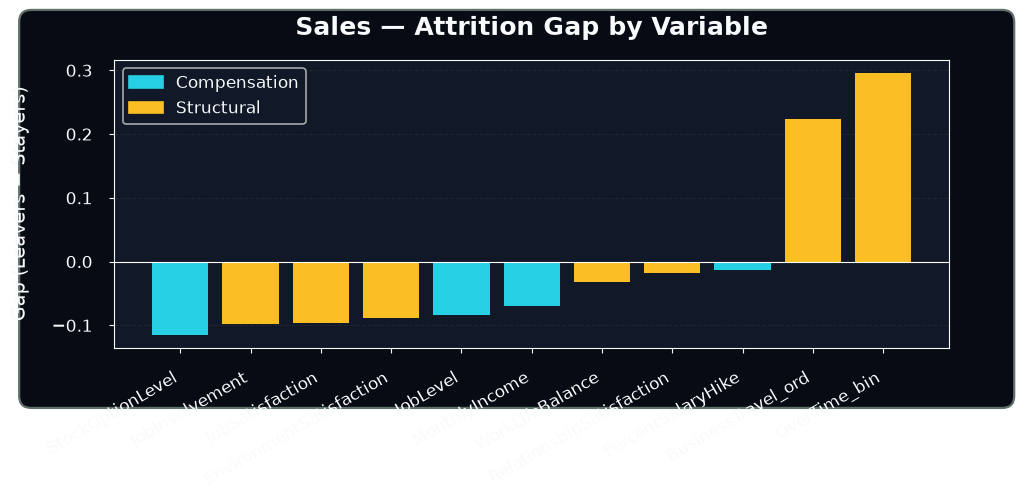



research_&_development_—_attrition_gap_by_variable saved!
                                                              •••




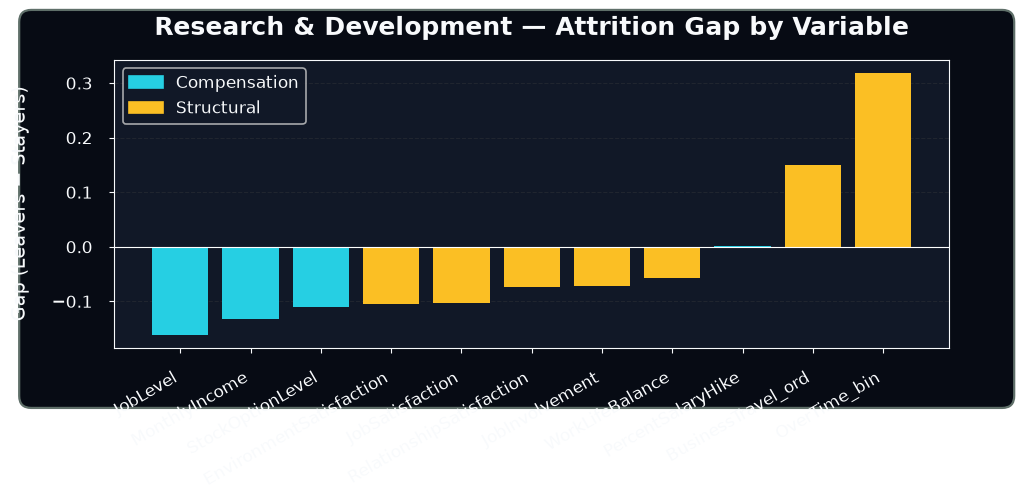



human_resources_—_attrition_gap_by_variable saved!
                                                              •••




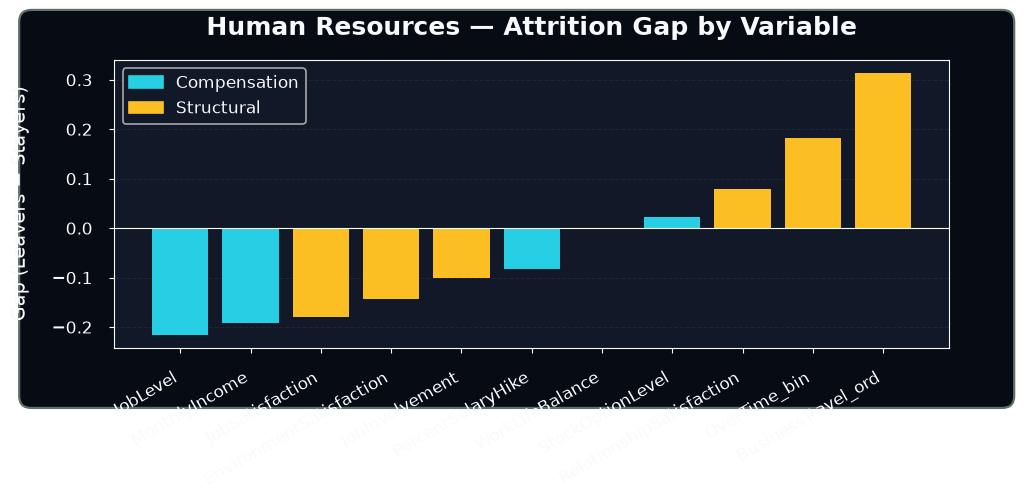

In [25]:
# Attrition Gap Analysis

comp_color = "#26CFE3"
struct_color = "#FBBF24"

departments = dfn["Department"].unique()

for dept in departments:

    dept_df = dfn[dfn["Department"] == dept]

    dept_rate = dept_df["Attrition_bin"].mean() * 100
    n_leavers = int(dept_df["Attrition_bin"].sum())

    gaps = {}

    for var in all_vars:
        leaver_mean = dept_df.loc[
            dept_df["Attrition_bin"] == 1, var
        ].mean()

        stayer_mean = dept_df.loc[
            dept_df["Attrition_bin"] == 0, var
        ].mean()

        gaps[var] = leaver_mean - stayer_mean

    # Sort from negative to positive
    gaps_series = pd.Series(gaps).sort_values()

    # Color by variable group
    colors = [
        comp_color if var in comp_vars else struct_color
        for var in gaps_series.index
    ]

    plt.figure(figsize=(10, 4))

    plt.bar(
        gaps_series.index,
        gaps_series.values,
        color=colors
    )

    plt.axhline(
        y=0,
        color="white",
        linewidth=0.8
    )

    # Legend for variable groups
    plt.legend(
        handles=[
            plt.Rectangle(
                (0, 0), 1, 1,
                color=comp_color,
                label="Compensation"
            ),
            plt.Rectangle(
                (0, 0), 1, 1,
                color=struct_color,
                label="Structural"
            )
        ],
        loc="best"
    )

    visualize_plot(
        plot_title=f"{dept} — Attrition Gap by Variable",
        x_label="",
        y_label="Gap (Leavers − Stayers)",
        show_grid=True,
        rotation=30
    )

> *Quite some observations here:*
> *1. Hypothesis 1 proved to be true. Sales department's attrition is dominantly defined by Overtime the employee works, which is a structural variable. Although a surprising insight is the second factor is business travel. A sales person should expect decent number of business trips, but here it deviates from the expectations. Whereas Stock Options and Job Involvement are resposible for loyality of the employees.*
> *2. Hypothesis 2 failed. Overtime is suprizingly the decding factor here, in R&D, followed by business travel. But Overtime in R&D is completely different from Overtime in Sales. R&D overtime may mean extended project hours, deadlines, product launches etc. The department should be analysed individually when proposing a solution. Job Level and Monthly income are retainers here. Seniors are more probable to stay, and higher income here actually makles a difference, unlike sales.*
> *3. HR attrition is mostly the Business Travel, which makes sense, since the job of HR is to find and recruit candidates, which often involves less of a travel. Business Trips is not what an HR expects. Second one is again a structural flaw, Overtime. Similar to R&D, Job Level and Monthly income are the retainers here.*

### Proposed Solutions:
1. In sales, a salary hike will just be an investment failure, since the actual attrition is a structural flaw - specifically Overtime and unpredictably more business travel. Therefore a fix in the system is required here, instead of the monetry compensation. Specifically, a lot less overtime, or no overtime, a lot less unexpected business travel and a bit more of stock options will keep the employees happy and loyal to the organisation for longer.
2. In R&D, adding a part of salary to the current will not save the employees from leaving. They need no or very less of overtime, less business trips - as the first three factors describe. The second factor is surprisingly, Business Travel. R&D employees who are assigned trips for work for engagement and coordination are instead leaving the company because of those. They donot require more income, since it is a positive parameter here, what they need is less overtime and more single-location work, which makes logical sense in R&D.
3. In HR, the fixes are indeed again surprising, not something a normal person would expect. The fix here would be a lot less business travel and  decrease in overtime, arranged based on priority with respect to the findings.

correlation_gap_heatmap saved!


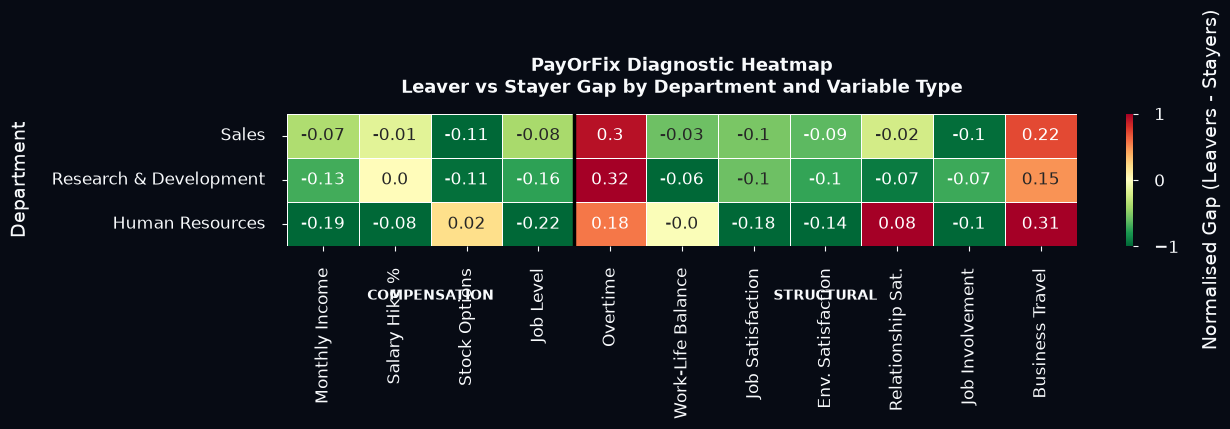

In [26]:
# Normalise gaps to make variables comparable across different scales

gap_matrix = pd.DataFrame()

for dept in dfn['Department'].unique():
    dept_df = dfn[dfn['Department'] == dept]

    leavers = dept_df[dept_df['Attrition_bin'] == 1]
    stayers = dept_df[dept_df['Attrition_bin'] == 0]

    gaps = {}

    for var in all_vars:
        leaver_mean = leavers[var].mean()
        stayer_mean = stayers[var].mean()

        gaps[var] = leaver_mean - stayer_mean

    gap_matrix.loc[dept, all_vars] = pd.Series(gaps)


# Separate normalisation for positive and negative gaps
gap_normalised = gap_matrix.copy()

for col in gap_matrix.columns:
    col_max = gap_matrix[col].abs().max()

    if col_max > 0:
        gap_normalised[col] = gap_matrix[col] / col_max


# Reorder columns: compensation variables first, structural second
ordered_cols = comp_vars + struct_vars

gap_normalised = gap_normalised[ordered_cols]


# Rename for readability
rename_map = {
    'MonthlyIncome': 'Monthly Income',
    'PercentSalaryHike': 'Salary Hike %',
    'StockOptionLevel': 'Stock Options',
    'JobLevel': 'Job Level',
    'OverTime_bin': 'Overtime',
    'WorkLifeBalance': 'Work-Life Balance',
    'JobSatisfaction': 'Job Satisfaction',
    'EnvironmentSatisfaction': 'Env. Satisfaction',
    'RelationshipSatisfaction': 'Relationship Sat.',
    'JobInvolvement': 'Job Involvement',
    'BusinessTravel_ord': 'Business Travel'
}

gap_normalised = gap_normalised.rename(columns=rename_map)

annot_matrix = gap_matrix[ordered_cols].round(2).rename(columns=rename_map)


# Plot
fig, ax = plt.subplots(figsize=(13, 4))

sns.heatmap(
    gap_normalised,
    annot=annot_matrix,
    fmt='',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Normalised Gap (Leavers - Stayers)'}
)

# Draw a vertical line separating compensation from structural variables
ax.axvline(x=len(comp_vars), color='black', linewidth=2.5)

ax.text(
    len(comp_vars) / 2,
    -0.4,
    'COMPENSATION',
    ha='center',
    fontsize=10,
    fontweight='bold',
    transform=ax.get_xaxis_transform()
)

ax.text(
    len(comp_vars) + len(struct_vars) / 2,
    -0.4,
    'STRUCTURAL',
    ha='center',
    fontsize=10,
    fontweight='bold',
    transform=ax.get_xaxis_transform()
)

ax.set_title(
    'PayOrFix Diagnostic Heatmap\nLeaver vs Stayer Gap by Department and Variable Type',
    fontsize=13,
    pad=15
)

ax.set_ylabel('Department')
ax.set_xlabel('')

plt.tight_layout()

save_plot('Correlation Gap Heatmap')

plt.show()

> *This heatmap is a master visual for looking onto all the gaps simultaneosuly.*

department-based_categorised_variables saved!


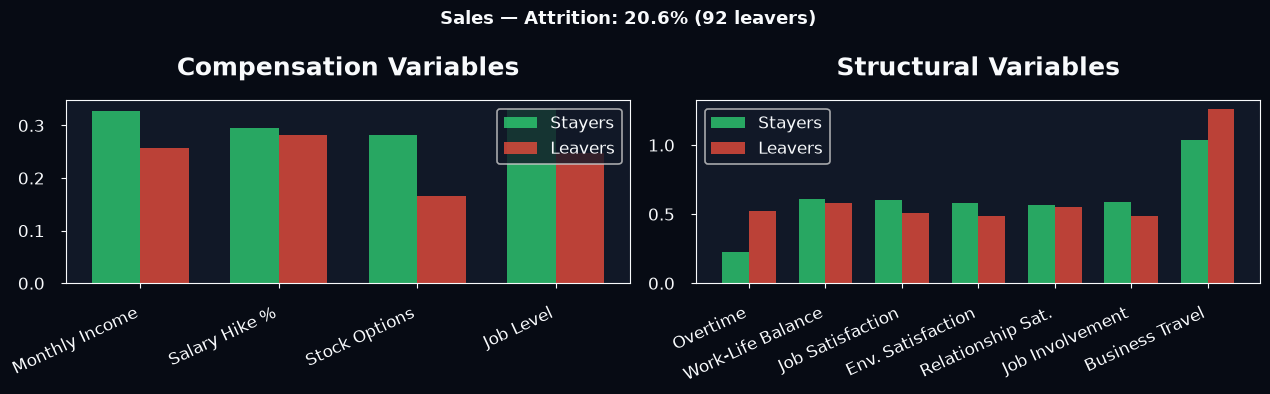

department-based_categorised_variables saved!


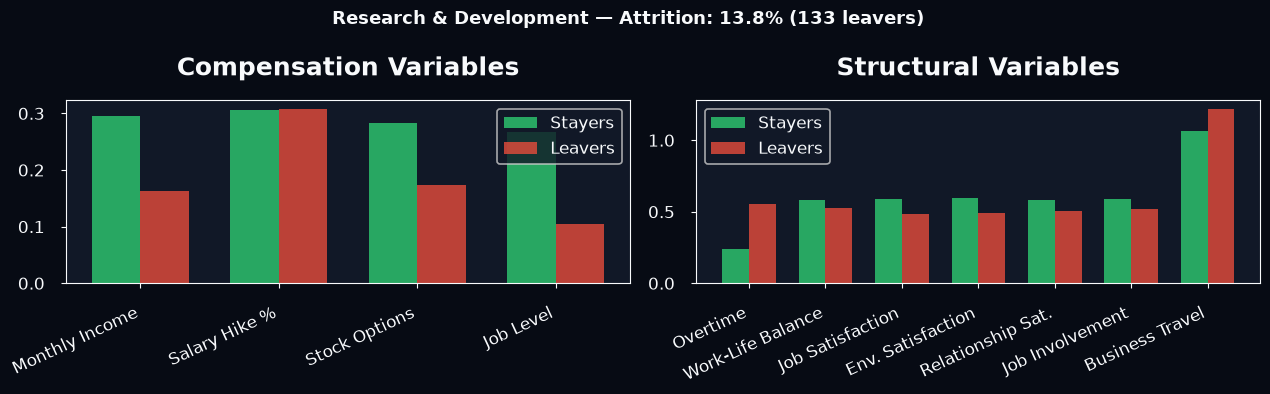

department-based_categorised_variables saved!


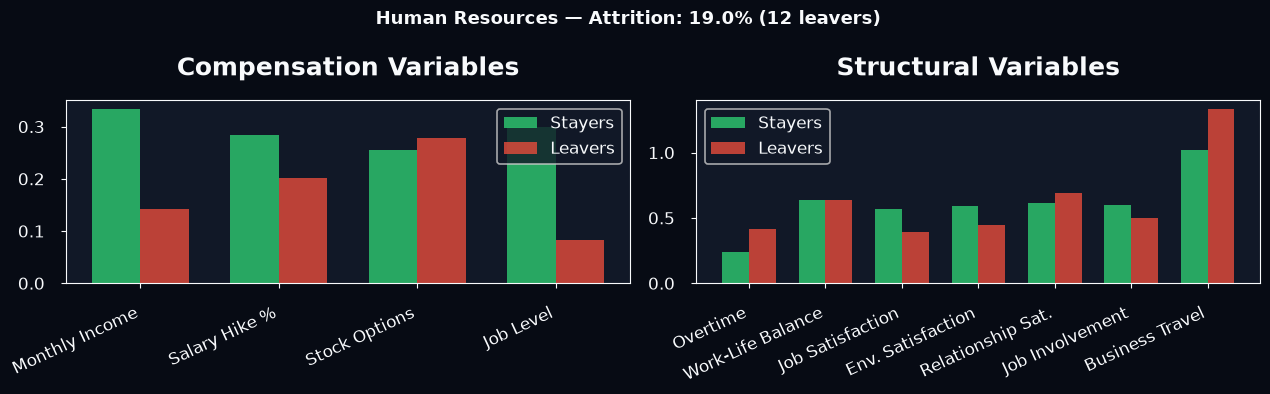

In [27]:
rename_map = {
    'MonthlyIncome': 'Monthly Income',
    'PercentSalaryHike': 'Salary Hike %',
    'StockOptionLevel': 'Stock Options',
    'JobLevel': 'Job Level',
    'OverTime_bin': 'Overtime',
    'WorkLifeBalance': 'Work-Life Balance',
    'JobSatisfaction': 'Job Satisfaction',
    'EnvironmentSatisfaction': 'Env. Satisfaction',
    'RelationshipSatisfaction': 'Relationship Sat.',
    'JobInvolvement': 'Job Involvement',
    'BusinessTravel_ord': 'Business Travel'
}
for dept in departments:
    dept_df = dfn[dfn['Department'] == dept]
    dept_rate = dept_df['Attrition_bin'].mean() * 100
    n_leavers = dept_df['Attrition_bin'].sum()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{dept} — Attrition: {dept_rate:.1f}% ({n_leavers} leavers)',
                 fontsize=13, fontweight='bold')

    for ax, (var_group, title, vars_list) in zip(axes, [
        ('Compensation', 'Compensation Variables', comp_vars),
        ('Structural', 'Structural Variables', struct_vars)
    ]):
        leavers_mean = dept_df[dept_df['Attrition_bin']==1][vars_list].mean()
        stayers_mean = dept_df[dept_df['Attrition_bin']==0][vars_list].mean()

        x = range(len(vars_list))
        width = 0.35
        ax.bar([i - width/2 for i in x], stayers_mean, width,
               label='Stayers', color='#2ecc71', alpha=0.8)
        ax.bar([i + width/2 for i in x], leavers_mean, width,
               label='Leavers', color='#e74c3c', alpha=0.8)
        ax.set_xticks(list(x))
        ax.set_xticklabels([rename_map.get(v, v) for v in vars_list], rotation=25, ha='right')
        ax.set_title(title)
        ax.legend()

    plt.tight_layout()
    save_plot('department-based categorised variables')
    plt.show()

> *Clear separation of the two variables in each department. A summary visual.*

In [28]:
# Sum of absolute gaps by variable type per department
departments = dfn['Department'].unique()
dept_gaps = {}

for dept in departments:
    dept_df = dfn[dfn['Department'] == dept]
    gaps = {}
    for var in all_vars:
        leaver_mean = dept_df[dept_df['Attrition_bin'] == 1][var].mean()
        stayer_mean = dept_df[dept_df['Attrition_bin'] == 0][var].mean()
        gaps[var] = leaver_mean - stayer_mean
    dept_gaps[dept] = gaps

gap_matrix = pd.DataFrame(dept_gaps).T
comp_signal = gap_matrix[comp_vars].abs().sum(axis=1)
struct_signal = gap_matrix[struct_vars].abs().sum(axis=1)

classification = pd.DataFrame({
    'Compensation Signal': comp_signal,
    'Structural Signal': struct_signal,
    'Dominant Type': np.where(comp_signal > struct_signal, 'Compensable', 'Structural'),
    'Attrition Rate (%)': df.groupby('Department')['Attrition_bin'].mean() * 100
})

print(classification)

                        Compensation Signal  Structural Signal Dominant Type  \
Human Resources                    0.511660           1.001634    Structural   
Research & Development             0.406046           0.878867    Structural   
Sales                              0.281108           0.854049    Structural   

                        Attrition Rate (%)  
Human Resources                  19.047619  
Research & Development           13.839750  
Sales                            20.627803  


> *A mathematical proof of what was observed earlier. Structural variables dominate the cause of attrition, in each department.*

> ##### Proved:
> ##### 1. Attrition in Sales Department is indeed mostly driven by structural variables - top 2 being Overtime and Business Travel.
> ##### 2. Attrition in R&D is driven by Business Travel and Overtime.
> ##### 3. The pay gap between stayers and leavers will be small - false in case of R&D and HR, true in case of Sales. Surprising, since sales department is expected to have income as its attrition cause.